# Real Images bilan Data Preparation 1

Ushbu notebook shu folder ichidagi **real image file** yordamida image classification’ning birinchi stepini tushuntiradi.

Biz real example sifatida `baliq.jpeg` dan foydalanamiz va quyidagilarni ko‘rib chiqamiz:

1. real image filelarni topish
2. real imageni loading qilish
3. size, mode va shapeni tekshirish
4. imagni pixel sonlariga aylantirish
5. imagni resizing va normalizing qilish
6. classification model uchun image datani tayyorlash

## 1. Kutubxonalarni Import qilish

Biz quyidagilardan foydalanamiz:

- `pathlib.Path` folder va filelar bilan ishlash uchun
- `PIL.Image` imagelarni load qilish va preprocess qilish uchun
- `numpy` imagelarni sonlar arrayiga aylantirish uchun

In [1]:
from pathlib import Path

from PIL import Image
import numpy as np

## 2. Folder ichidagi Real Imagelarni topish

Fake generated imagelardan foydalanish o‘rniga, ushbu notebook project folder ichida allaqachon saqlangan real image filelarni qidiradi.

In [2]:
project_dir = Path('.')
image_extensions = {'.jpg', '.jpeg', '.png', '.webp'}
real_images = [p for p in project_dir.iterdir() if p.is_file() and p.suffix.lower() in image_extensions]

for image_path in real_images:
    print(image_path.name)

print('Total real images found:', len(real_images))

baliq.jpeg
Total real images found: 1


## 3. Bitta Real Imageni tanlash

Bu yerda biz `baliq.jpeg` ni tanlaymiz, u shu folder ichidagi real image file hisoblanadi.

Image path: baliq.jpeg
Image mode: RGB
Image size (width, height): (601, 332)


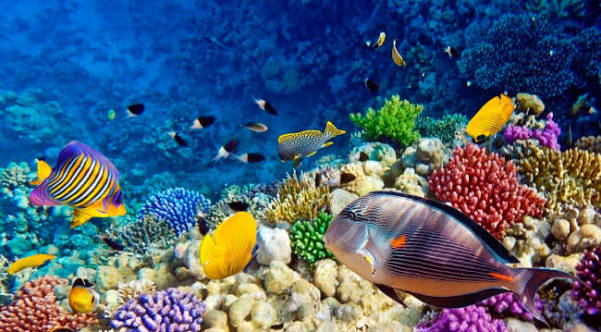

In [3]:
image_path = Path('baliq.jpeg')
img = Image.open(image_path)

print('Image path:', image_path)
print('Image mode:', img.mode)
print('Image size (width, height):', img.size)

img

### Tushuntirish

- `Image.open(...)` diskdan real imageni load qiladi.
- `img.mode` bizga image turini aytadi, masalan RGB.
- `img.size` original image sizeni beradi.

Bu image classification projectlarida haqiqiy boshlang‘ich nuqta hisoblanadi.

## 4. Real Imageni RGB ga Convert qilish

Ko‘p image classification pipelinelari imagelarni RGB ga convert qiladi, shunda hamma data bir xil formatga ega bo‘ladi.

Converted mode: RGB


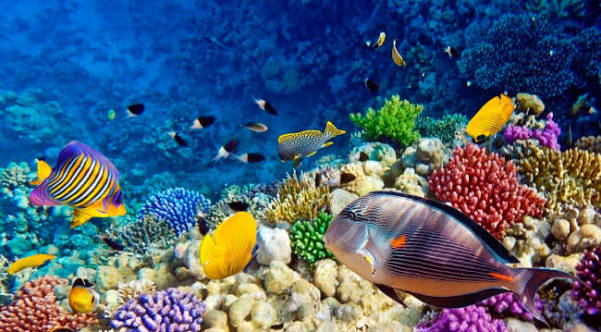

In [4]:
img_rgb = img.convert('RGB')

print('Converted mode:', img_rgb.mode)
img_rgb

## 5. Real Imageni Pixel sonlariga aylantirish

Model rasmlarni to‘g‘ridan-to‘g‘ri tushunmaydi.

U sonlardan o‘rganadi, shuning uchun biz real imageni NumPy arrayga aylantiramiz.

In [5]:
img_array = np.array(img_rgb)

print('Array shape:', img_array.shape)
print('Array dtype:', img_array.dtype)

Array shape: (332, 601, 3)
Array dtype: uint8


### Shape tushuntirishi

RGB image uchun shape odatda quyidagicha ko‘rinadi:

```python
(height, width, 3)
```

Bu degani:

- birinchi qiymat = height
- ikkinchi qiymat = width
- `3` = Red, Green, Blue channels

## 6. Real Imagedagi Pixel qiymatlarini tekshirish

Endi studentlar real image aslida pixel qiymatlaridan iborat grid ekanini ko‘rishlari mumkin.

In [6]:
print('First pixel:', img_array[0, 0])
print('Top-left 5x5 pixels:')
print(img_array[:5, :5, :])

First pixel: [  0  87 205]
Top-left 5x5 pixels:
[[[  0  87 205]
  [  0  88 205]
  [  0  89 206]
  [  0  92 208]
  [  0  95 210]]

 [[  0  90 207]
  [  0  91 208]
  [  0  93 209]
  [  0  94 210]
  [  0  97 212]]

 [[  1  95 211]
  [  1  95 211]
  [  1  96 212]
  [  2  97 213]
  [  2  99 214]]

 [[  2  99 214]
  [  3 100 215]
  [  3 100 215]
  [  4 101 216]
  [  2 102 216]]

 [[  2 103 217]
  [  2 103 217]
  [  3 103 217]
  [  3 103 217]
  [  3 103 217]]]


### Tushuntirish

RGB imagedagi har bir pixel uchta qiymatga ega bo‘ladi:

```python
[R, G, B]
```

Misol:

- `[255, 0, 0]` red degani
- `[0, 255, 0]` green degani
- `[0, 0, 255]` blue degani

## 7. Real Imageni Resize qilish

Image classification’da barcha input imagelar odatda bir xil size bo‘lishi kerak.

Resized image size: (224, 224)


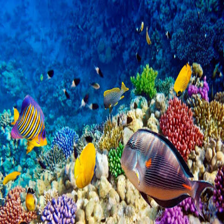

In [7]:
target_size = (224, 224)
img_resized = img_rgb.resize(target_size)

print('Resized image size:', img_resized.size)
img_resized

## 8. Resize qilingan Imageni Modelga tayyor Arrayga aylantirish

Resize qilingandan keyin, image model input size bilan mos bo‘lishi uchun uni yana sonlarga aylantiramiz.

In [8]:
resized_array = np.array(img_resized)

print('Resized array shape:', resized_array.shape)
print('First pixel after resize:', resized_array[0, 0])

Resized array shape: (224, 224, 3)
First pixel after resize: [  0  89 206]


## 9. Pixel qiymatlarini Normalize qilish

Real image pixellari odatda `0` dan `255` gacha bo‘ladi.

Ko‘p deep learning modellari qiymatlar `0.0` dan `1.0` gacha scale qilinganda yaxshiroq ishlaydi.

In [9]:
normalized_array = resized_array / 255.0

print('Normalized shape:', normalized_array.shape)
print('Normalized dtype:', normalized_array.dtype)
print('Min value:', normalized_array.min())
print('Max value:', normalized_array.max())
print('First normalized pixel:', normalized_array[0, 0])

Normalized shape: (224, 224, 3)
Normalized dtype: float64
Min value: 0.0
Max value: 1.0
First normalized pixel: [0.         0.34901961 0.80784314]


## 10. Real Image uchun Label yaratish

Classification uchun har bir image labelga ega bo‘lishi kerak.

Bu image cat, shuning uchun unga `baliq` labelini berishimiz mumkin.

In [10]:
label = 'baliq'
label_to_index = {'baliq': 0, 'ilon': 1}
encoded_label = label_to_index[label]

print('Text label:', label)
print('Encoded label:', encoded_label)

Text label: baliq
Encoded label: 0


## 11. Bitta Model Input Example yaratish

Tayyorlangan classification sample quyidagilardan iborat bo‘ladi:

- image data sonlar ko‘rinishida
- label son ko‘rinishida

In [11]:
X = normalized_array
y = encoded_label

print('Input image shape:', X.shape)
print('Target label:', y)

Input image shape: (224, 224, 3)
Target label: 0


# 12. Qayta ishlatish mumkin bo‘lgan Data Preparation Function yozish.hammasi bitta funksiyani ichida

Bu function real image uchun asosiy preparation steplarni birlashtiradi.

Prepared image shape: (224, 224, 3)
Prepared label: 0


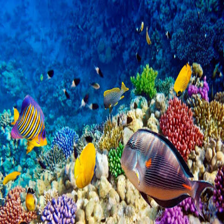

In [12]:
def prepare_real_image(image_path, label, label_map, target_size=(128, 128)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0
    encoded_label = label_map[label]
    return img, img_array, encoded_label


prepared_img, prepared_array, prepared_label = prepare_real_image(
    image_path='baliq.jpeg',
    label='baliq',
    label_map={'baliq': 0, 'ilon': 1},
    target_size=(224, 224),
)

print('Prepared image shape:', prepared_array.shape)
print('Prepared label:', prepared_label)
prepared_img

## 13. Summary

Ushbu notebookda biz **real image**dan foydalandik va quyidagilarni o‘rgandik:

- real image filelarni topish
- diskdan real imageni load qilish
- uni RGB ga convert qilish
- uni pixel sonlariga aylantirish
- image shape va pixel qiymatlarini tekshirish
- imageni resize qilish
- imageni normalize qilish
- labelni encode qilish
- modelga tayyor bitta training example yaratish